# **LAB 01**

## **Task 1 - Data Scraping**
* Create a Scrapy spider that follows catalog pagination and visits each individual book page.
* Extract all required fields and export the raw records to CSV or JSON format.
* Report the total number of scraped records, missing values, and duplicate UPC values.

In [1]:
!pip install scrapy Twisted

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.4/350.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 8.6 MB/s eta 0:00:00


In [2]:
%%writefile book_spider.py
import scrapy

class BookSpider(scrapy.Spider):
    name = "books"
    start_urls = ['https://books.toscrape.com/catalogue/page-1.html']
    page_count = 1

    def parse(self, response):
        book_links = response.css('h3 a::attr(href)').getall()
        for link in book_links:
            yield response.follow(link, callback=self.parse_book)

        next_page = response.css('li.next a::attr(href)').get()
        if next_page and self.page_count < 7:
            self.page_count += 1
            yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        def get_table_row(name):
            return response.xpath(f"//th[text()='{name}']/following-sibling::td/text()").get(default='').strip()

        yield {
            'title': response.css('div.product_main h1::text').get(default='').strip(),
            'category': response.xpath('//ul[@class="breadcrumb"]/li[3]/a/text()').get(default='').strip(),
            'price': response.css('p.price_color::text').get(default='').strip(),
            'rating': response.css('p.star-rating::attr(class)').get(default='').replace('star-rating', '').strip(),
            'availability': get_table_row('Availability'),
            'product_description': response.xpath('//div[@id="product_description"]/following-sibling::p/text()').get(default=''),
            'UPC': get_table_row('UPC'),
            'number_of_reviews': get_table_row('Number of reviews'),
            'product_url': response.url
        }

Writing book_spider.py


In [3]:
!scrapy runspider book_spider.py -o books_raw.csv

2026-08-06 15:06:49 [scrapy.utils.log] INFO: Scrapy 2.17.0 started (bot: scrapybot)
2026-08-06 15:06:49 [scrapy.utils.log] INFO: Versions:
{'lxml': '6.1.1',
 'libxml2': '2.14.6',
 'cssselect': '1.5.0',
 'parsel': '1.11.0',
 'w3lib': '2.4.1',
 'Twisted': '26.4.0',
 'Python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]',
 'pyOpenSSL': '26.3.0 (OpenSSL 4.0.1 9 Jun 2026)',
 'cryptography': '49.0.0',
 'Platform': 'Linux-6.6.122+-x86_64-with-glibc2.35'}
2026-08-06 15:06:49 [scrapy.crawler] DEBUG: Using AsyncCrawlerProcess
2026-08-06 15:06:49 [asyncio] DEBUG: Using selector: EpollSelector
2026-08-06 15:06:49 [scrapy.addons] INFO: Enabled addons:
[]
2026-08-06 15:06:49 [scrapy.utils.log] DEBUG: Using reactor: twisted.internet.asyncioreactor.AsyncioSelectorReactor
2026-08-06 15:06:49 [scrapy.utils.log] DEBUG: Using asyncio event loop: asyncio.unix_events._UnixSelectorEventLoop
2026-08-06 15:06:49 [scrapy.extensions.telnet] INFO: Telnet Password: 25beff763e6cada6
2026-08-06 15:06:49 [scr

In [4]:
import pandas as pd

# Load the newly scraped data
df_raw = pd.read_csv('books_raw.csv')

print("TASK 1 REPORT")
print(f"Total number of scraped records: {len(df_raw)}")
print(f"Duplicate UPC values: {df_raw['UPC'].duplicated().sum()}")
print("\nMissing values per column:")
print(df_raw.isnull().sum())

df_raw.head()

TASK 1 REPORT
Total number of scraped records: 140
Duplicate UPC values: 0

Missing values per column:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64


,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...
2,The Requiem Red,Young Adult,£22.65,One,In stock (19 available),Patient Twenty-nine.A monster roams the halls ...,f77dbf2323deb740,0,https://books.toscrape.com/catalogue/the-requi...
3,"Starving Hearts (Triangular Trade Trilogy, #1)",Default,£13.99,Two,In stock (19 available),"Since her assault, Miss Annette Chetwynd has b...",0312262ecafa5a40,0,https://books.toscrape.com/catalogue/starving-...
4,Scott Pilgrim's Precious Little Life (Scott Pi...,Sequential Art,£52.29,Five,In stock (19 available),Scott Pilgrim's life is totally sweet. He's 23...,3b1c02bac2a429e6,0,https://books.toscrape.com/catalogue/scott-pil...


## **Task 2 - Data Preprocessing**
* Clean up extra spaces and inconsistent text; remove duplicate books by UPC; handle missing
descriptions.
* Convert price to a numeric value, map ratings One-Five to integers, and extract the available stock
count.
* Create at least three useful features, such as description_word_count, price_band, affordability_score,
value_score, or recommended.

In [15]:
import numpy as np
import pandas as pd

In [5]:
df_raw['availability'].unique()

array(['In stock (19 available)', 'In stock (20 available)',
       'In stock (18 available)', 'In stock (17 available)',
       'In stock (16 available)', 'In stock (22 available)',
       'In stock (15 available)'], dtype=object)

In [16]:
df_raw['product_description'].replace(r'^\s*$', np.nan, regex=True).isna().sum()

np.int64(0)

In [18]:
df_raw['rating'].unique()

array(['Two', 'Three', 'One', 'Five', 'Four'], dtype=object)

In [23]:
df_raw['UPC'].value_counts() #by default desc

,count
UPC,
a22124811bfa8350,1
deda3e61b9514b83,1
f77dbf2323deb740,1
0312262ecafa5a40,1
3b1c02bac2a429e6,1
...,...
d7d6d50c1e3d0b81,1
8a380641491d43ed,1
70ed59f194b3c556,1


In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv('books_raw.csv')

# Strip extra whitespaces
df['title'] = df['title'].str.strip()
df['category'] = df['category'].str.strip()

# empty spaces to NaN to No description
df['product_description'] = df['product_description'].replace(r'^\s*$', np.nan, regex=True)
df['product_description'] = df['product_description'].fillna("No description available.")

# Remove duplicate books by UPC
df = df.drop_duplicates(subset=['UPC'])

# Convert price to a proper numeric value
df['price'] = df['price'].astype(str).str.extract(r'([0-9.]+)').astype(float)

# Map text ratings to integers
rating_mapping = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df['rating'] = df['rating'].map(rating_mapping)

# Extract the available stock count r'\d+' any digit + -> one or more and if no digits
df['stock_count'] = df['availability'].str.extract(r'(\d+)').astype(float).fillna(1).astype(int)


# adding description_word_count
df['description_word_count'] = df['product_description'].apply(lambda x: len(str(x).split()))

# adding price_band
df['price_band'] = pd.qcut(df['price'], q=3, labels=['Budget', 'Average', 'Premium'])

# adding value_score
df['value_score'] = round((df['rating'] / df['price']) * 10, 2)

# cleaned dataset
df.to_csv('books_cleaned.csv', index=False)

# Preview the newly engineered columns
df[['title', 'price', 'rating', 'stock_count', 'price_band', 'value_score']].head()

,title,price,rating,stock_count,price_band,value_score
0,It's Only the Himalayas,45.17,2,19,Premium,0.44
1,Our Band Could Be Your Life: Scenes from the A...,57.25,3,19,Premium,0.52
2,The Requiem Red,22.65,1,19,Budget,0.44
3,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2,19,Budget,1.43
4,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5,19,Premium,0.96


In [25]:
df_cleaned = pd.read_csv('books_cleaned.csv')
df_cleaned.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url,stock_count,description_word_count,price_band,value_score
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,Premium,0.44
1,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,Premium,0.52
2,The Requiem Red,Young Adult,22.65,1,In stock (19 available),Patient Twenty-nine.A monster roams the halls ...,f77dbf2323deb740,0,https://books.toscrape.com/catalogue/the-requi...,19,170,Budget,0.44
3,"Starving Hearts (Triangular Trade Trilogy, #1)",Default,13.99,2,In stock (19 available),"Since her assault, Miss Annette Chetwynd has b...",0312262ecafa5a40,0,https://books.toscrape.com/catalogue/starving-...,19,196,Budget,1.43
4,Scott Pilgrim's Precious Little Life (Scott Pi...,Sequential Art,52.29,5,In stock (19 available),Scott Pilgrim's life is totally sweet. He's 23...,3b1c02bac2a429e6,0,https://books.toscrape.com/catalogue/scott-pil...,19,148,Premium,0.96


## **Task 3 - Visualization and Analysis**
* Generate at least four meaningful plots, including price distribution, rating distribution, average price
by category, and one relationship plot such as price vs rating or category vs stock.
* Generate a word cloud from the combined book descriptions. The selected website does not provide
written customer-review text, so descriptions must be used as the textual source.
* Use summary statistics and plots to identify category patterns, highly rated books, stock patterns, and
any unusual or missing values.

/tmp/ipykernel_2443/1934939067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='Blues_d', ax=axes[0, 1])
/tmp/ipykernel_2443/1934939067.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='price', data=df, palette='Set2', ax=axes[1, 1])


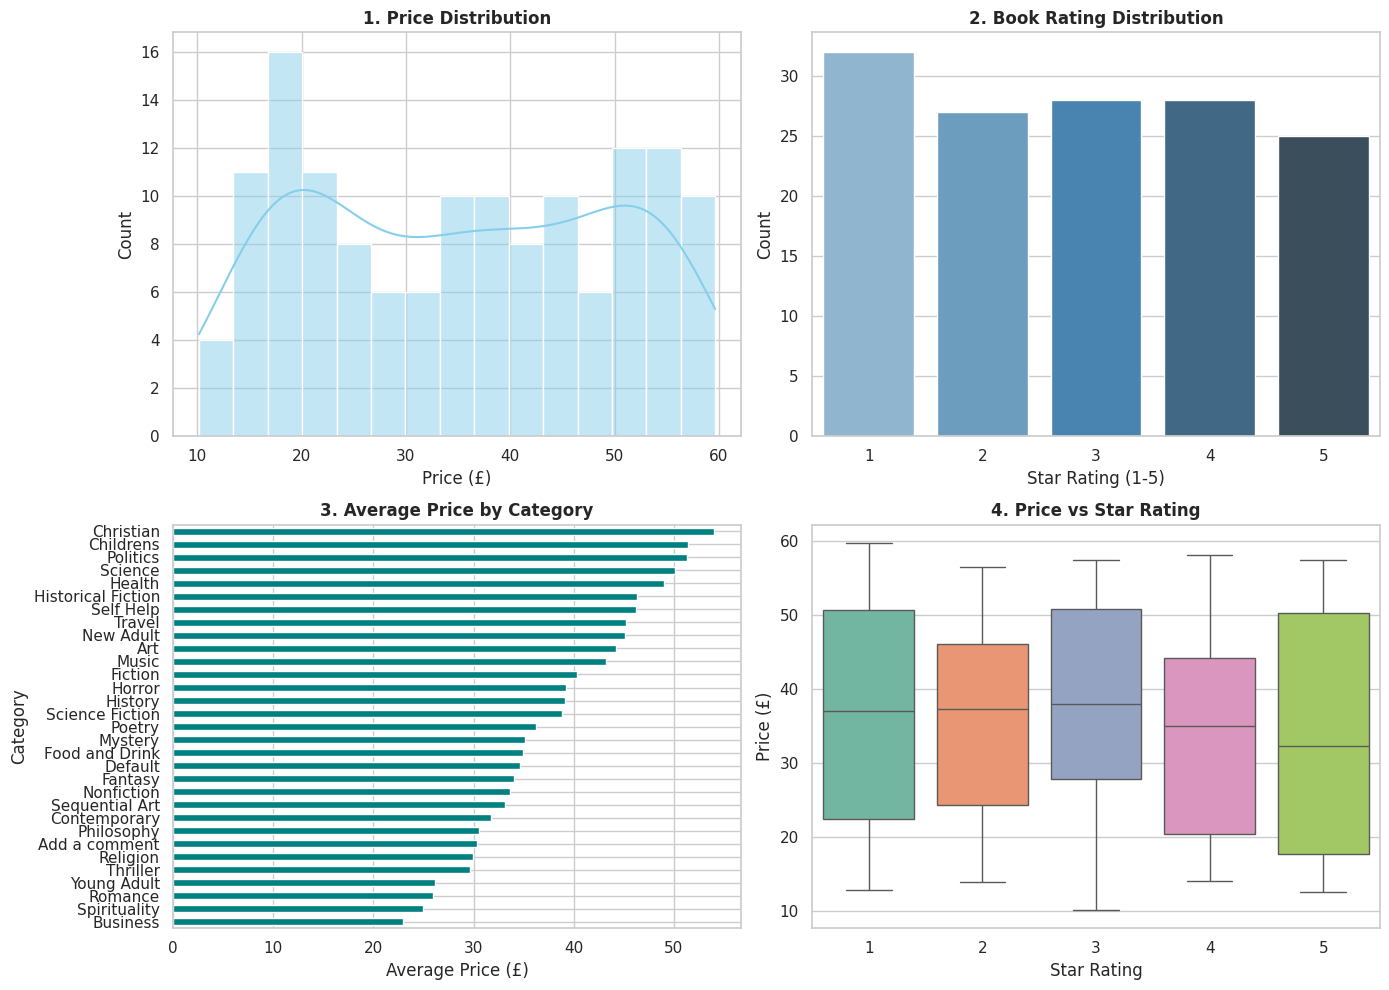

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# Create a figure canvas with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price Distribution
sns.histplot(df['price'], kde=True, color='skyblue', ax=axes[0, 0], bins=15)
axes[0, 0].set_title('1. Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (£)')
axes[0, 0].set_ylabel('Count')

# 2. Rating Distribution
sns.countplot(x='rating', data=df, palette='Blues_d', ax=axes[0, 1])
axes[0, 1].set_title('2. Book Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Star Rating (1-5)')
axes[0, 1].set_ylabel('Count')

# 3. Average Price by Category
avg_price_cat = df.groupby('category')['price'].mean().sort_values(ascending=True)
avg_price_cat.plot(kind='barh', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('3. Average Price by Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Average Price (£)')
axes[1, 0].set_ylabel('Category')

# 4. Relationship Plot: Price vs Rating (Boxplot)
sns.boxplot(x='rating', y='price', data=df, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('4. Price vs Star Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Star Rating')
axes[1, 1].set_ylabel('Price (£)')

plt.tight_layout()
plt.savefig('plots_overview.png', dpi=300)
plt.show()

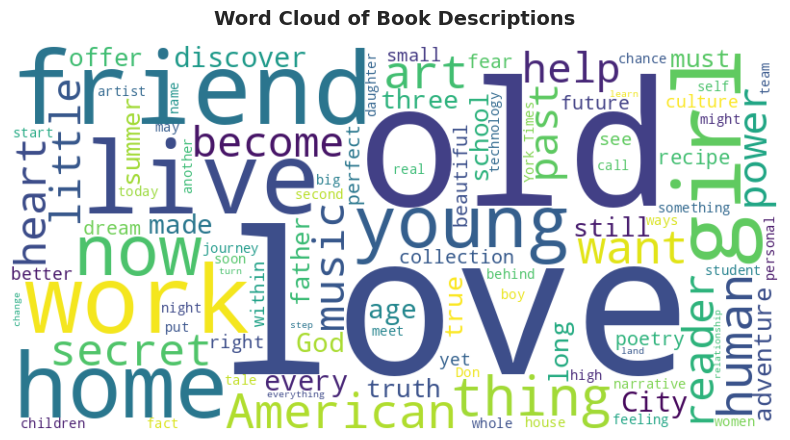

In [35]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine all book descriptions into a single block of text
combined_text = " ".join(desc for desc in df['product_description'])

# Enhanced stopwords list
book_blurb_stopwords = {
    # Single letter noise & contraction remnants
    's', 'u', 't', 're', 've', 'll', 'd', 'us',

    # Generic book/publishing terms
    'book', 'books', 'story', 'stories', 'novel', 'author', 'written', 'writer',
    'page', 'pages', 'chapter', 'edition', 'series', 'volume', 'publication',

    # Common character/plot descriptors
    'character', 'characters', 'life', 'world', 'time', 'year', 'years', 'day',
    'people', 'man', 'woman', 'family', 'way', 'part', 'history', 'place',

    # Common blurb verbs
    'one', 'two', 'new', 'will', 'read', 'reads', 'reading', 'first', 'find',
    'finds', 'take', 'takes', 'make', 'makes', 'know', 'knows', 'tell', 'tells',
    'show', 'shows', 'explore', 'explores', 'set', 'sets', 'come', 'comes',
    'get', 'gets', 'includes', 'including', 'brings', 'gives',

    # Generic adverbs & adjectives
    'also', 'even', 'well', 'like', 'just', 'great', 'best', 'full', 'many',
    'much', 'never', 'ever', 'always', 'back', 'along', 'around', 'through'
}

custom_stopwords = set(STOPWORDS).union(book_blurb_stopwords)

# Generate the word cloud with min_word_length=3
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    colormap='viridis',
    min_word_length=3,  # Filters out 1 and 2 letter fragments
    max_words=100
).generate(combined_text)

# Plot the cleaned word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Book Descriptions', fontsize=14, fontweight='bold', pad=15)

# Save image for GitHub
plt.savefig('wordcloud.png', dpi=300)
plt.show()

In [36]:

print(df[['price', 'rating', 'stock_count', 'description_word_count', 'value_score']].describe())

print("\n Top Categories by Book Count")
print(df['category'].value_counts())

print("\n Top 5 Highest Value Books (Best Rating relative to Price) ")
print(df.sort_values(by='value_score', ascending=False)[['title', 'price', 'rating', 'value_score']].head(5))

print("\n Stock Pattern Summary ")
print(f"Total Available Inventory across sampled books: {df['stock_count'].sum()} units")
print(f"Average stock per title: {df['stock_count'].mean():.2f} units")

            price      rating  stock_count  description_word_count  \
count  140.000000  140.000000   140.000000              140.000000   
mean    35.347214    2.907143    16.757143              231.764286   
std     14.524483    1.423828     1.438782              102.893785   
min     10.160000    1.000000    15.000000               36.000000   
25%     21.937500    2.000000    16.000000              167.500000   
50%     35.370000    3.000000    16.000000              217.500000   
75%     49.152500    4.000000    18.000000              278.000000   
max     59.640000    5.000000    22.000000              722.000000   

       value_score  
count   140.000000  
mean      1.041429  
std       0.825220  
min       0.170000  
25%       0.510000  
50%       0.775000  
75%       1.362500  
max       3.970000  

 Top Categories by Book Count
category
Sequential Art        21
Nonfiction            15
Default               14
Fantasy                8
Poetry                 7
Fiction        

## **Task 4 - Insights and Interpretation**
* Write 5-7 clear observations supported by numerical results or plots.
* Explain whether price appears related to rating, which categories are most represented or expensive,
and which books provide the best value.
* Conclude with a brief discussion of the limitations of the scraped dataset and the analysis.

In [37]:
df.groupby('rating')['price'].agg(['mean', 'median', 'count'])

,mean,median,count
rating,,,
1,36.332500,37.010,32
2,35.644074,37.320,27
3,37.269643,37.915,28
4,33.728571,35.030,28
5,33.425200,32.240,25


We can conclude that there's no correlation among book ratings and prices as the price increases from ratings 1 to 3 and then it dips from rating 4 to 5, this indicates that ratings don't affect prices and prices don't affect book ratings as there is no clear single trend. There is no steady linear or invese correlation between the two variables.

In [38]:
df['category'].value_counts().head(3)

,count
category,
Sequential Art,21
Nonfiction,15
Default,14


This shows 'default' as top 3 counts of genre which happens when the publisher doesn't assign any specific genre or category for the book while uploading the data or the book on the portal, this may lead to books not reaching the right audiences and going way underrepresented.


In [39]:
df.groupby('category')['price'].mean().nlargest(3)

,price
category,
Christian,54.000
Childrens,51.435
Politics,51.330


This shows top 3 most expenisive categories of books.

In [40]:
df.groupby('category')['price'].mean().nsmallest(3)

,price
category,
Business,22.975
Spirituality,24.950
Romance,25.970


3 Least expensive categpries.

In [41]:
df.nlargest(3, 'value_score')[['title', 'category', 'price', 'rating', 'value_score']]

,title,category,price,rating,value_score
122,The Third Wave: An Entrepreneur’s Vision of th...,Business,12.61,5,3.97
94,Princess Between Worlds (Wide-Awake Princess #5),Fantasy,13.34,5,3.75
96,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",Sequential Art,13.61,5,3.67


This tells us the top 3 best books by ratings and price.
These books have the best value_score values which indicate they have the best ratings to price ratio (*10). Which can mean one can have a good read without spending a lot of amount.

In [42]:
df['price'].agg(['min', 'median', 'mean', 'max'])

,price
min,10.160000
median,35.370000
mean,35.347214
max,59.640000


These indicates the prices around which our books are listed around in our scraped data. With books sellling for 10 to around 60 pounds.
With values mostly centered around 35 pounds.

In [43]:
df['stock_count'].agg(['min', 'mean', 'max', 'sum'])

,stock_count
min,15.000000
mean,16.757143
max,22.000000
sum,2346.000000


This shows most of the books are in stock and inventories are upto date in order to keep copies of different books with most of the books having atleast 15 copies in stock.

## **Conclude with a brief discussion of the limitations of the scraped dataset and the analysis.**

ASSUMING AND CONCLUDING FROM THE POINT OF VIEW THAT THE DATA IS AN ACTUAL SOURCE OF DATA AND NOT FROM A PRACTICE SITE

The data is heavily skewed with only few categories with major count values like Sequential Art and nonfiction, this leads to an imbalance between the categories representation and conclusions.

The above is also the result of the limited data we scraped from the sites leading to an imbalanced data and underrepresentation and overrepresentation of categories. This also makes our conclusions lack generalizability as they are made on a very biased sample of data. Another better approach would have been scraping data randomly instead of the sequential sorted order the site holds it in.

As we scraped directly from page 1 to 7 and with reference the conclusion made above, we can conclude the home page of the site is arranged categorical wise and should be arranged randomly instead of a specific sorting in order for users to come across random and different genres of books at once. This may help specially with new and regular users to come across new books and categories of novels.

The word count plot doesn't summarise any significant words as they are derived from book descriptions, which adds no important information about the books or their likability. Something like customer reviews would have been a better information source about the collection of wide varieties of novels available on the website.

This tells us our data doesn't hold many attributes to show customer likings and dislikes apart from the ratings.